# HSV Banana Ripeness Classification

## 1. Introduction

Banana ripeness progresses through four visible classes — **unripe, ripe, overripe, and rotten** — and these stages are strongly associated with changes in peel colour. This notebook implements a complete classical image-processing and machine-learning pipeline using the **HSV (Hue, Saturation, Value)** colour space.

HSV is useful for this task because it separates colour information from brightness. **Hue (H)** represents the dominant colour, **Saturation (S)** describes colour intensity, and **Value (V)** represents brightness. This separation allows the banana peel colour to be analysed while reducing the direct influence of illumination variation.

The complete workflow is:

**dataset loading → resize to a 416×416 target when necessary → median filtering → RGB-to-HSV conversion → V-channel enhancement → banana segmentation → morphological refinement → HSV histogram feature extraction → StandardScaler() → SVC() → train / validation / test evaluation**

The original dataset split is preserved throughout the experiment. No hyperparameter tuning is performed so that the HSV method follows the same classifier protocol used by the other colour-space approaches in the group project.


## 2. Import Libraries


In [1]:
from __future__ import annotations
%matplotlib inline

import math
import random
import time
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Iterable, Sequence

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_SEED = 42
TARGET_SIZE = (416, 416)  # preprocessing resize target: width, height
CLASS_ORDER = ["unripe", "ripe", "overripe", "rotten"]
SUBSETS = ("train", "valid", "test")
EXPECTED_COUNTS = {"train": 11793, "valid": 1123, "test": 562}
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# HSV approach: fixed image-processing settings
MEDIAN_KERNEL = 3
H_MIN = 0
H_MAX = 90
S_MIN = 35
S_MAX = 255
MORPH_KERNEL = 5
MORPH_OPEN_ITERATIONS = 1
MORPH_CLOSE_ITERATIONS = 1
CONNECTIVITY = 8

# HSV histogram feature settings stated in the methodology
H_BINS = 16
S_BINS = 8
V_BINS = 8

H_FEATURES = [f"H_bin_{index:02d}" for index in range(1, H_BINS + 1)]
S_FEATURES = [f"S_bin_{index:02d}" for index in range(1, S_BINS + 1)]
V_FEATURES = [f"V_bin_{index:02d}" for index in range(1, V_BINS + 1)]
HSV_HISTOGRAM_FEATURES = H_FEATURES + S_FEATURES + V_FEATURES

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


## 3. Dataset Preparation

The **Banana Ripeness Classification** dataset is used with its original **train / validation / test** split unchanged. The split is not recreated or randomly shuffled, ensuring that every colour-space method in the group evaluates the same dataset partitions.

The original dataset images are **not required to have a fixed native resolution**. During preprocessing, **416 × 416 pixels is used only as the target resize size**. If an input image already matches the target size, it is kept unchanged; otherwise, it is resized to 416 × 416 using OpenCV interpolation. This follows the same resize preparation used in the CIELAB implementation and gives the HSV pipeline a consistent processing size without imposing a fixed-resolution requirement on the source dataset.

The validation folder is detected using common names such as `valid`, `validation`, or `val`, while the displayed terminology is standardised as **Validation**.

The dataset structure, class folders, image counts, and expected total number of images are verified before feature extraction begins. This helps prevent missing classes, incorrect paths, or incomplete dataset processing.


In [2]:
DATASET_DIR = Path(
    r"C:\Users\User\Downloads\Banana Ripeness Classification Dataset"
)

if not DATASET_DIR.is_dir():
    raise FileNotFoundError(f"Dataset directory does not exist: {DATASET_DIR}")

timestamp = datetime.now().astimezone().strftime("%Y%m%d_%H%M%S_%z")
RESULTS_DIR = (Path.cwd() / "results" / timestamp).resolve()

suffix = 1
while RESULTS_DIR.exists():
    RESULTS_DIR = RESULTS_DIR.with_name(f"{timestamp}_{suffix:02d}")
    suffix += 1

FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True)

print(f"Dataset: {DATASET_DIR}")
print(f"Outputs: {RESULTS_DIR}")


Dataset: C:\Users\User\Downloads\Banana Ripeness Classification Dataset
Outputs: C:\Users\User\Downloads\results\20260905_173437_+0800


The dataset structure and image counts are verified before image processing.


In [3]:
class DatasetError(RuntimeError):
    """Raised when the dataset structure or an image is invalid."""


@dataclass(frozen=True)
class ImageRecord:
    """One deterministic dataset image entry."""
    path: Path
    relative_path: Path
    subset: str
    class_name: str


def resolve_subset_directory(root: Path, subset: str) -> Path:
    """Resolve an original dataset subset, accepting valid/validation aliases."""
    aliases = {
        "train": ("train", "training"),
        "valid": ("valid", "validation", "val"),
        "test": ("test", "testing"),
    }

    matches = [root / name for name in aliases[subset] if (root / name).is_dir()]

    if len(matches) != 1:
        raise DatasetError(
            f"Expected exactly one directory for {subset}; found {matches}"
        )

    return matches[0]


def iter_image_records(
    root: Path,
    subsets: Sequence[str] = SUBSETS
) -> Iterable[ImageRecord]:
    """Yield images deterministically by subset, class, and relative path."""
    for subset in subsets:
        subset_dir = resolve_subset_directory(root, subset)

        actual_classes = sorted(
            path.name for path in subset_dir.iterdir() if path.is_dir()
        )

        if set(actual_classes) != set(CLASS_ORDER):
            raise DatasetError(
                f"{subset_dir} classes are {actual_classes}; expected {CLASS_ORDER}"
            )

        for class_name in CLASS_ORDER:
            class_dir = subset_dir / class_name

            paths = sorted(
                (
                    path for path in class_dir.rglob("*")
                    if path.is_file()
                    and path.suffix.lower() in IMAGE_EXTENSIONS
                ),
                key=lambda path: path.relative_to(root).as_posix().lower(),
            )

            for path in paths:
                yield ImageRecord(
                    path.resolve(),
                    path.relative_to(root),
                    subset,
                    class_name,
                )


records = list(iter_image_records(DATASET_DIR))

manifest = pd.DataFrame([
    {
        "image_path": record.relative_path.as_posix(),
        "subset": record.subset,
        "ground_truth_class": record.class_name,
    }
    for record in records
])

if manifest.empty or not manifest["image_path"].is_unique:
    raise DatasetError(
        "The dataset manifest is empty or contains duplicate relative paths."
    )

dataset_counts = (
    manifest
    .groupby(["subset", "ground_truth_class"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(index=SUBSETS, columns=CLASS_ORDER)
)

dataset_counts["Total"] = dataset_counts.sum(axis=1)
dataset_counts.loc["Total"] = dataset_counts.sum(axis=0)

display(dataset_counts.rename(index={"valid": "validation"}))

for subset, expected in EXPECTED_COUNTS.items():
    actual = int((manifest["subset"] == subset).sum())

    if actual != expected:
        raise DatasetError(
            f"{subset} has {actual} images; expected {expected}"
        )

if len(records) != 13478:
    raise DatasetError(
        f"Found {len(records)} images; expected 13,478"
    )

manifest.to_csv(
    RESULTS_DIR / "dataset_manifest.csv",
    index=False
)


ground_truth_class,unripe,ripe,overripe,rotten,Total
subset,,,,,
train,1902,3522,2349,4020,11793
validation,167,339,229,388,1123
test,110,154,113,185,562
Total,2179,4015,2691,4593,13478


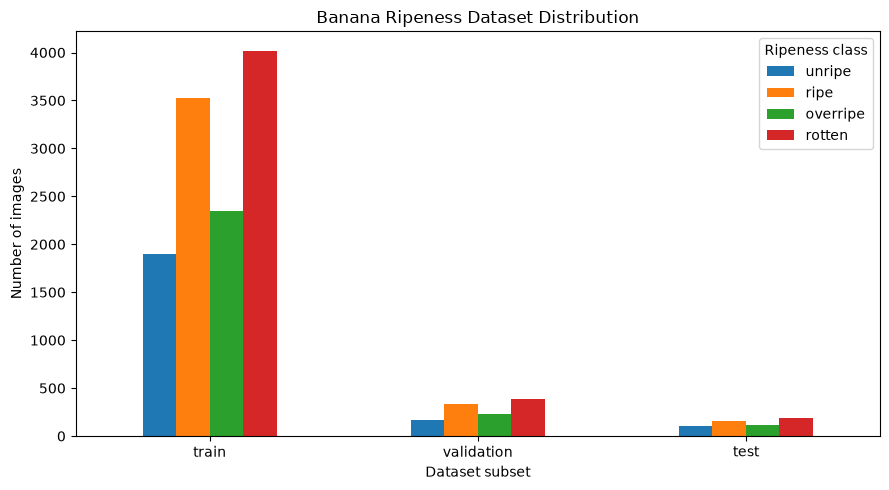

In [4]:
# Dataset distribution by subset and class

plot_counts = dataset_counts.drop(
    index="Total"
).drop(
    columns="Total"
)

ax = plot_counts.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Banana Ripeness Dataset Distribution")
ax.set_xlabel("Dataset subset")
ax.set_ylabel("Number of images")

plt.xticks(ticks=range(len(plot_counts.index)), labels=["train", "validation", "test"], rotation=0)
plt.legend(title="Ripeness class")
plt.tight_layout()
plt.show()


## 4. Image Preprocessing

Each image is first decoded with OpenCV and converted from **BGR to RGB** so that colour handling remains consistent with the rest of the notebook. The original image resolution may vary. The RGB image is resized to the **416 × 416 processing target only when necessary**.

A **3 × 3 median filter** is applied after resizing. Median filtering reduces isolated noise and small compression artefacts while preserving important object boundaries better than simple averaging. Preserving the banana outline is important because the next stages depend on colour-based segmentation of the peel region.

The preprocessing settings are fixed for the full experiment and are applied identically to training, validation, and testing images. No subset receives a different preprocessing procedure.


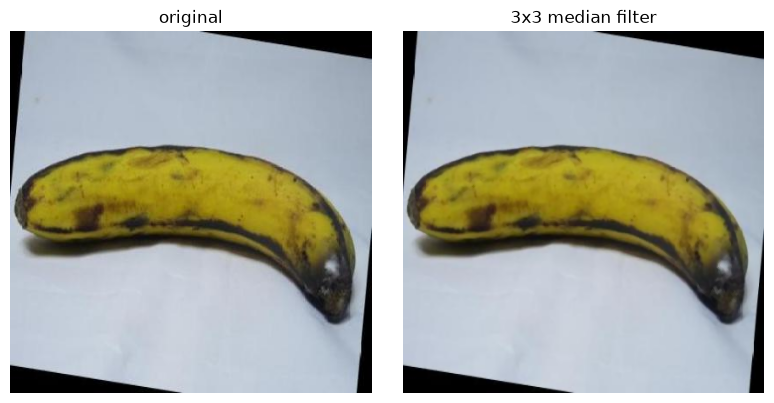

In [5]:
def load_native_rgb(record: ImageRecord) -> np.ndarray:
    """Decode one image and resize to the 416 x 416 processing target only when necessary."""
    try:
        encoded = np.fromfile(record.path, dtype=np.uint8)
        bgr = cv2.imdecode(encoded, cv2.IMREAD_COLOR)
    except Exception as exc:
        raise DatasetError(f"Could not read {record.path}: {exc}") from exc

    if bgr is None:
        raise DatasetError(f"OpenCV could not decode {record.path}")

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    if rgb.shape[:2] != (TARGET_SIZE[1], TARGET_SIZE[0]):
        rgb = cv2.resize(rgb, TARGET_SIZE, interpolation=cv2.INTER_AREA)

    return rgb


def median_filter(rgb: np.ndarray) -> np.ndarray:
    return cv2.medianBlur(rgb, MEDIAN_KERNEL)


sample_record = next(record for record in records if record.subset == "train" and record.class_name == "overripe")
sample_rgb = load_native_rgb(sample_record)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(sample_rgb)
ax[0].set_title("original")
ax[0].axis("off")
ax[1].imshow(median_filter(sample_rgb))
ax[1].set_title("3x3 median filter")
ax[1].axis("off")
plt.tight_layout()
plt.show()


## 5. HSV Colour Conversion and V-Channel Enhancement

After preprocessing, the RGB image is converted to the **HSV colour space**.

- **Hue (H)** represents the dominant colour and is useful for distinguishing green, yellow, brown, and darker peel tones associated with different ripeness stages.
- **Saturation (S)** represents colour intensity and helps separate strongly coloured banana regions from low-saturation background areas.
- **Value (V)** represents brightness.

To reduce ordinary brightness variation, histogram equalisation is applied to the **V channel only**. H and S are retained so that the original hue and saturation information used for ripeness discrimination is not directly modified.

### Banana Region Segmentation

The banana region is isolated using fixed **H–S colour ranges**. Pixels satisfying the configured HSV conditions are combined into a binary banana mask. Morphological operations are then used to remove small isolated regions and fill small gaps in the detected peel area.

Where appropriate, connected-region refinement is used to retain the main banana region and reduce background detections. The same frozen segmentation settings are used for all train, validation, and test images; they are not changed after inspecting test performance.

This stage is important because feature extraction should describe the **banana peel**, rather than the entire image background.


In [6]:
class PipelineError(RuntimeError):
    """Raised when an image, HSV channel, mask, or frozen parameter is invalid."""


@dataclass(frozen=True)
class MaskDiagnostics:
    foreground_area_ratio: float
    component_count: int
    largest_component_ratio: float
    automatic_status: str
    suspicious_reasons: str


@dataclass(frozen=True)
class SegmentationResult:
    filtered_rgb: np.ndarray
    hsv_original: np.ndarray
    hsv_equalised: np.ndarray
    initial_mask: np.ndarray
    refined_mask: np.ndarray
    final_mask: np.ndarray
    extracted_rgb: np.ndarray
    diagnostics: MaskDiagnostics


def validate_rgb(rgb: np.ndarray) -> None:
    """Validate an 8-bit RGB image."""
    if (
        not isinstance(rgb, np.ndarray)
        or rgb.ndim != 3
        or rgb.shape[2] != 3
        or rgb.dtype != np.uint8
    ):
        raise PipelineError(
            f"Expected uint8 RGB image; received {getattr(rgb, 'shape', None)}"
        )


def validate_mask(mask: np.ndarray) -> np.ndarray:
    """Validate and normalize a binary mask to 0 and 255."""
    if (
        not isinstance(mask, np.ndarray)
        or mask.ndim != 2
        or mask.dtype != np.uint8
    ):
        raise PipelineError(
            "Expected a two-dimensional uint8 mask"
        )

    return np.where(mask > 0, 255, 0).astype(np.uint8)


def prepare_hsv_channels(rgb: np.ndarray) -> dict[str, np.ndarray]:
    """Apply median filtering, HSV conversion, and V-only histogram equalisation."""
    validate_rgb(rgb)

    filtered = cv2.medianBlur(
        rgb,
        MEDIAN_KERNEL
    )

    hsv_original = cv2.cvtColor(
        filtered,
        cv2.COLOR_RGB2HSV
    )

    h_channel, s_channel, v_original = cv2.split(
        hsv_original
    )

    v_equalised = cv2.equalizeHist(
        v_original
    )

    hsv_equalised = cv2.merge(
        (h_channel, s_channel, v_equalised)
    )

    return {
        "median_rgb": filtered,
        "hsv_original": hsv_original,
        "hsv_equalised": hsv_equalised,
        "h_channel": h_channel.copy(),
        "s_channel": s_channel.copy(),
        "v_original": v_original.copy(),
        "v_equalised": v_equalised.copy(),
    }


def hs_range_threshold(
    hsv_equalised: np.ndarray
) -> np.ndarray:
    """Apply the frozen H-S range threshold."""
    lower = np.array(
        [H_MIN, S_MIN, 0],
        dtype=np.uint8
    )

    upper = np.array(
        [H_MAX, S_MAX, 255],
        dtype=np.uint8
    )

    return cv2.inRange(
        hsv_equalised,
        lower,
        upper
    )


def morphological_refinement(
    mask: np.ndarray
) -> np.ndarray:
    """Apply one elliptical 5 x 5 opening followed by one closing."""
    refined = validate_mask(mask)

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (MORPH_KERNEL, MORPH_KERNEL)
    )

    refined = cv2.morphologyEx(
        refined,
        cv2.MORPH_OPEN,
        kernel,
        iterations=MORPH_OPEN_ITERATIONS
    )

    refined = cv2.morphologyEx(
        refined,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=MORPH_CLOSE_ITERATIONS
    )

    return refined


def keep_largest_component(
    mask: np.ndarray
) -> tuple[np.ndarray, int, float]:
    """Keep the largest connected foreground component."""
    binary = (
        validate_mask(mask) > 0
    ).astype(np.uint8)

    count, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            binary,
            connectivity=CONNECTIVITY
        )
    )

    component_count = max(count - 1, 0)

    if component_count == 0:
        return (
            np.zeros_like(mask),
            0,
            0.0
        )

    areas = stats[
        1:,
        cv2.CC_STAT_AREA
    ]

    largest_label = 1 + int(
        np.argmax(areas)
    )

    total_foreground = max(
        int(np.sum(areas)),
        1
    )

    largest_area = int(
        stats[
            largest_label,
            cv2.CC_STAT_AREA
        ]
    )

    largest_component_ratio = (
        largest_area / total_foreground
    )

    final_mask = np.where(
        labels == largest_label,
        255,
        0
    ).astype(np.uint8)

    return (
        final_mask,
        component_count,
        largest_component_ratio
    )


def mask_diagnostics(
    refined_mask: np.ndarray,
    final_mask: np.ndarray,
    component_count: int,
    largest_component_ratio: float
) -> MaskDiagnostics:
    """Calculate simple frozen mask diagnostics; this is not segmentation accuracy."""
    final = validate_mask(final_mask)

    area_ratio = (
        np.count_nonzero(final)
        / final.size
    )

    reasons = []

    if not np.any(final):
        reasons.append("empty_mask")

    if area_ratio < 0.01:
        reasons.append(
            "excessively_small_mask"
        )

    if area_ratio > 0.90:
        reasons.append(
            "excessively_large_mask"
        )

    if (
        component_count > 0
        and largest_component_ratio < 0.45
    ):
        reasons.append(
            "low_largest_component_ratio"
        )

    if component_count > 25:
        reasons.append(
            "too_many_components"
        )

    return MaskDiagnostics(
        foreground_area_ratio=float(area_ratio),
        component_count=int(component_count),
        largest_component_ratio=float(
            largest_component_ratio
        ),
        automatic_status=(
            "suspicious"
            if reasons
            else "automatic_check_passed"
        ),
        suspicious_reasons=";".join(
            dict.fromkeys(reasons)
        ),
    )


def extract_banana_region(
    rgb: np.ndarray,
    mask: np.ndarray,
    background_value: int = 255
) -> np.ndarray:
    """Keep original filtered RGB banana pixels and set the background to white."""
    validate_rgb(rgb)

    binary = validate_mask(mask)

    if binary.shape != rgb.shape[:2]:
        raise PipelineError(
            "Mask and image sizes differ"
        )

    extracted = np.full_like(
        rgb,
        background_value
    )

    extracted[binary > 0] = rgb[binary > 0]

    return extracted


def frozen_hsv_segmentation(
    rgb: np.ndarray
) -> SegmentationResult:
    """Run the complete frozen HSV segmentation path."""
    channels = prepare_hsv_channels(rgb)

    initial_mask = hs_range_threshold(
        channels["hsv_equalised"]
    )

    refined_mask = morphological_refinement(
        initial_mask
    )

    final_mask, component_count, largest_ratio = (
        keep_largest_component(
            refined_mask
        )
    )

    diagnostics = mask_diagnostics(
        refined_mask,
        final_mask,
        component_count,
        largest_ratio
    )

    extracted = extract_banana_region(
        channels["median_rgb"],
        final_mask
    )

    return SegmentationResult(
        filtered_rgb=channels["median_rgb"],
        hsv_original=channels["hsv_original"],
        hsv_equalised=channels["hsv_equalised"],
        initial_mask=initial_mask,
        refined_mask=refined_mask,
        final_mask=final_mask,
        extracted_rgb=extracted,
        diagnostics=diagnostics
    )


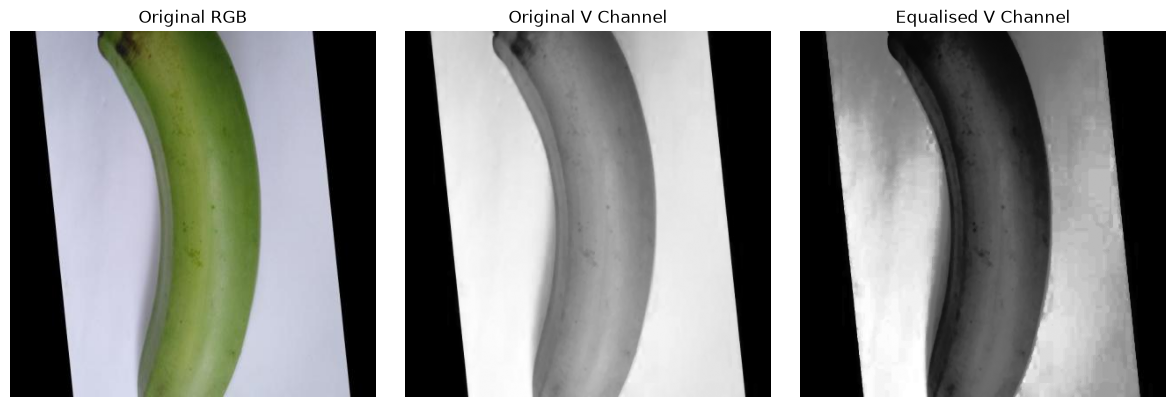

In [7]:
# Demonstration of V-channel histogram equalisation

sample_record = next(
    record for record in records
    if record.subset == "train"
)

rgb = load_native_rgb(sample_record)
channels = prepare_hsv_channels(rgb)

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4)
)

axes[0].imshow(rgb)
axes[0].set_title("Original RGB")

axes[1].imshow(
    channels["v_original"],
    cmap="gray"
)
axes[1].set_title("Original V Channel")

axes[2].imshow(
    channels["v_equalised"],
    cmap="gray"
)
axes[2].set_title("Equalised V Channel")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


## 6. Feature Extraction

After segmentation, only pixels belonging to the cleaned banana mask are used to construct the HSV feature vector.

The method uses **normalised colour histograms**:

- **Hue:** 16 bins
- **Saturation:** 8 bins
- **Value:** 8 bins

The three histograms are concatenated to produce a **32-dimensional HSV feature vector** for each image.

Histogram features describe the distribution of peel colours rather than relying on a single mean colour value. This is useful for banana ripeness because a banana can contain several peel colours at the same time, especially during transitions from green to yellow and from yellow to brown or black.

Each histogram is normalised so that the feature representation is less dependent on the number of segmented pixels. Therefore, images with different banana-region sizes can still be compared using the same 32 feature dimensions.


In [8]:
@dataclass(frozen=True)
class FeatureOutcome:
    feature_row: dict[str, object] | None
    failure_row: dict[str, object] | None


def normalised_histogram(
    channel: np.ndarray,
    mask: np.ndarray,
    bins: int,
    value_range: list[int]
) -> np.ndarray:
    """Return one L1-normalised histogram inside the banana mask."""
    binary = validate_mask(mask)

    histogram = cv2.calcHist(
        [channel],
        [0],
        binary,
        [bins],
        value_range
    ).flatten().astype(np.float64)

    total = histogram.sum()

    if total <= 0:
        raise PipelineError(
            "Histogram contains no valid banana pixels"
        )

    return histogram / total


def hsv_histogram_features(
    hsv_equalised: np.ndarray,
    mask: np.ndarray
) -> dict[str, float]:
    """Return the frozen 16-H + 8-S + 8-V normalised histogram features."""
    h_channel, s_channel, v_channel = cv2.split(
        hsv_equalised
    )

    h_hist = normalised_histogram(
        h_channel,
        mask,
        H_BINS,
        [0, 180]
    )

    s_hist = normalised_histogram(
        s_channel,
        mask,
        S_BINS,
        [0, 256]
    )

    v_hist = normalised_histogram(
        v_channel,
        mask,
        V_BINS,
        [0, 256]
    )

    values = np.concatenate(
        [h_hist, s_hist, v_hist]
    )

    return {
        name: float(value)
        for name, value in zip(
            HSV_HISTOGRAM_FEATURES,
            values
        )
    }


def extract_base_features(
    record: ImageRecord
) -> FeatureOutcome:
    """Extract frozen HSV histogram features from one raw image."""
    started = time.perf_counter()

    base = {
        "image_path": record.relative_path.as_posix(),
        "subset": record.subset,
        "ground_truth_class": record.class_name,
    }

    try:
        rgb = load_native_rgb(record)

        result = frozen_hsv_segmentation(
            rgb
        )

        if not np.any(result.final_mask):
            raise PipelineError(
                "Frozen HSV segmentation produced an empty mask"
            )

        features = hsv_histogram_features(
            result.hsv_equalised,
            result.final_mask
        )

        elapsed = (
            time.perf_counter()
            - started
        )

        row = {
            **base,
            **features,
            "mask_area_ratio":
                result.diagnostics.foreground_area_ratio,
            "segmentation_status": "success",
            "suspicious_mask":
                result.diagnostics.automatic_status
                == "suspicious",
            "suspicious_reasons":
                result.diagnostics.suspicious_reasons,
            "component_count":
                result.diagnostics.component_count,
            "largest_component_ratio":
                result.diagnostics.largest_component_ratio,
            "processing_time_seconds":
                elapsed,
        }

        return FeatureOutcome(
            row,
            None
        )

    except Exception as exc:
        elapsed = (
            time.perf_counter()
            - started
        )

        return FeatureOutcome(
            None,
            {
                **base,
                "failure_type":
                    type(exc).__name__,
                "failure_message":
                    str(exc),
                "processing_time_seconds":
                    elapsed,
            }
        )


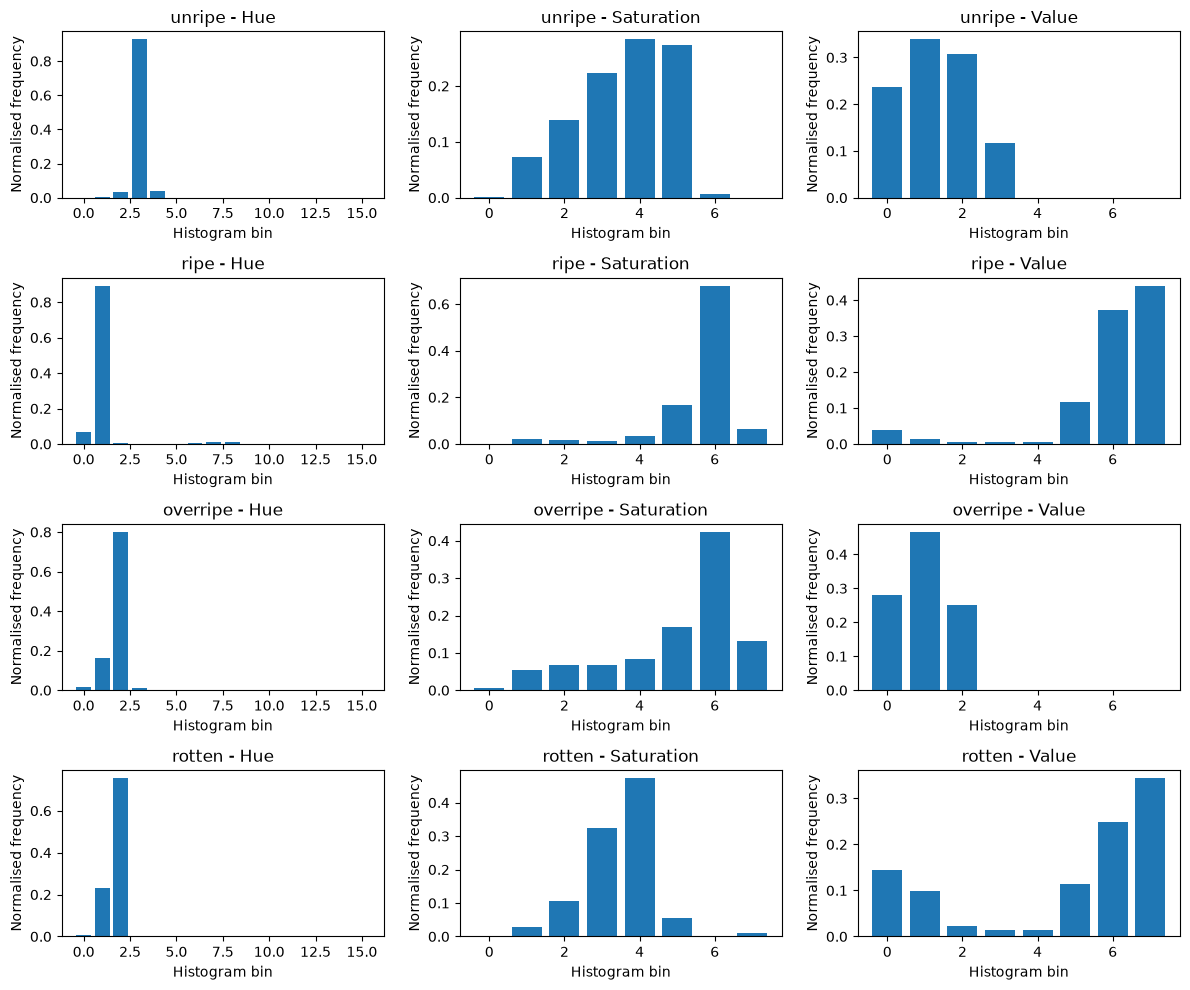

In [9]:
# HSV histogram comparison across ripeness classes

fig, axes = plt.subplots(
    len(CLASS_ORDER),
    3,
    figsize=(12, 10)
)

for row, class_name in enumerate(CLASS_ORDER):

    record = next(
        record for record in records
        if record.subset == "train"
        and record.class_name == class_name
    )

    rgb = load_native_rgb(record)
    result = frozen_hsv_segmentation(rgb)

    h, s, v = cv2.split(
        result.hsv_equalised
    )

    channels = [
        (h, H_BINS, [0, 180], "Hue"),
        (s, S_BINS, [0, 256], "Saturation"),
        (v, V_BINS, [0, 256], "Value"),
    ]

    for col, (channel, bins, value_range, title) in enumerate(channels):

        hist = cv2.calcHist(
            [channel],
            [0],
            result.final_mask,
            [bins],
            value_range
        ).flatten()

        if hist.sum() > 0:
            hist = hist / hist.sum()

        axes[row, col].bar(
            range(len(hist)),
            hist
        )

        axes[row, col].set_title(
            f"{class_name} - {title}"
        )

        axes[row, col].set_xlabel("Histogram bin")
        axes[row, col].set_ylabel("Normalised frequency")

plt.tight_layout()
plt.show()


## 7. Feature Preparation

The complete dataset is processed using the same frozen HSV pipeline. For every image, the notebook performs preprocessing, HSV conversion, V-channel enhancement, segmentation, morphological refinement, and 32-dimensional histogram extraction.

The extracted features are kept according to the original **train / validation / test** split. The resulting matrices are checked for consistent feature length and valid numerical values before classification.

The experiment follows a two-stage model protocol:

1. A **development model** is fitted using the training subset only. This model is used to report Training and Validation performance.
2. After the image-processing method has been fixed, a **final model** is fitted using the combined Training + Validation data and is evaluated once on the untouched Test subset.

This prevents the test subset from being used to select image-processing settings or classifier settings and keeps the evaluation procedure consistent with the other group methods.

Processing time is also recorded so that the computational cost of the HSV image-processing and feature-extraction pipeline can be reported.


In [10]:
feature_rows = []
failure_rows = []

processing_started = time.perf_counter()
total_images = len(records)

for index, record in enumerate(
    records,
    start=1
):
    outcome = extract_base_features(
        record
    )

    if outcome.feature_row is not None:
        feature_rows.append(
            outcome.feature_row
        )
    else:
        failure_rows.append(
            outcome.failure_row
        )

    if (
        index % 1000 == 0
        or index == total_images
    ):
        elapsed = (
            time.perf_counter()
            - processing_started
        )

        print(
            f"[features] {index:,}/{total_images:,} processed; "
            f"failures={len(failure_rows)}; "
            f"elapsed={elapsed:.1f}s"
        )

total_processing_time = (
    time.perf_counter()
    - processing_started
)

base_features = pd.DataFrame(
    feature_rows
)

failures = pd.DataFrame(
    failure_rows,
    columns=[
        "image_path",
        "subset",
        "ground_truth_class",
        "failure_type",
        "failure_message",
        "processing_time_seconds",
    ]
)

base_features.to_csv(
    RESULTS_DIR / "base_hsv_histogram_features.csv",
    index=False
)

failures.to_csv(
    RESULTS_DIR / "missing_or_invalid_features.csv",
    index=False
)

print(
    f"Total feature-processing time: "
    f"{total_processing_time:.1f}s"
)


[features] 1,000/13,478 processed; failures=0; elapsed=11.9s
[features] 2,000/13,478 processed; failures=0; elapsed=23.9s
[features] 3,000/13,478 processed; failures=0; elapsed=34.7s
[features] 4,000/13,478 processed; failures=0; elapsed=46.1s
[features] 5,000/13,478 processed; failures=0; elapsed=57.3s
[features] 6,000/13,478 processed; failures=0; elapsed=68.9s
[features] 7,000/13,478 processed; failures=0; elapsed=79.1s
[features] 8,000/13,478 processed; failures=0; elapsed=89.3s
[features] 9,000/13,478 processed; failures=0; elapsed=100.6s
[features] 10,000/13,478 processed; failures=0; elapsed=111.5s
[features] 11,000/13,478 processed; failures=0; elapsed=122.0s
[features] 12,000/13,478 processed; failures=0; elapsed=132.8s
[features] 13,000/13,478 processed; failures=0; elapsed=143.7s
[features] 13,478/13,478 processed; failures=0; elapsed=148.7s
Total feature-processing time: 148.7s


The complete 32-feature matrices and processing-time summaries are prepared below.


In [11]:
histogram_configuration = pd.DataFrame([
    {
        "Channel": "H",
        "Number of bins": H_BINS,
        "OpenCV range": "0-179",
        "Number of features": len(H_FEATURES),
    },
    {
        "Channel": "S",
        "Number of bins": S_BINS,
        "OpenCV range": "0-255",
        "Number of features": len(S_FEATURES),
    },
    {
        "Channel": "V",
        "Number of bins": V_BINS,
        "OpenCV range": "0-255",
        "Number of features": len(V_FEATURES),
    },
])

display(histogram_configuration)

subset_features = {}

for subset in SUBSETS:
    frame = (
        base_features
        .loc[
            base_features["subset"]
            == subset
        ]
        .reset_index(drop=True)
    )

    subset_features[subset] = frame

    frame.to_csv(
        RESULTS_DIR
        / f"{subset}_hsv_histogram_features.csv",
        index=False
    )

feature_shapes = pd.DataFrame([
    {
        "Subset": ("validation" if subset == "valid" else subset),
        "Number of images":
            len(subset_features[subset]),
        "Number of features":
            len(HSV_HISTOGRAM_FEATURES),
    }
    for subset in SUBSETS
])

processing_summary = pd.DataFrame([
    {
        "Subset": ("validation" if subset == "valid" else subset),
        "Images processed":
            int(
                (
                    manifest["subset"]
                    == subset
                ).sum()
            ),
        "Failures":
            int(
                (
                    failures["subset"]
                    == subset
                ).sum()
            )
            if not failures.empty
            else 0,
        "Suspicious masks":
            int(
                subset_features[subset][
                    "suspicious_mask"
                ].astype(bool).sum()
            ),
        "Mean processing time":
            float(
                subset_features[subset][
                    "processing_time_seconds"
                ].mean()
            ),
    }
    for subset in SUBSETS
])

display(feature_shapes)
display(processing_summary)

histogram_configuration.to_csv(
    RESULTS_DIR / "hsv_histogram_configuration.csv",
    index=False
)

feature_shapes.to_csv(
    RESULTS_DIR / "feature_matrix_shapes.csv",
    index=False
)

processing_summary.to_csv(
    RESULTS_DIR / "processing_summary.csv",
    index=False
)


,Channel,Number of bins,OpenCV range,Number of features
0,H,16,0-179,16
1,S,8,0-255,8
2,V,8,0-255,8


,Subset,Number of images,Number of features
0,train,11793,32
1,validation,1123,32
2,test,562,32


,Subset,Images processed,Failures,Suspicious masks,Mean processing time
0,train,11793,0,440,0.011044
1,validation,1123,0,39,0.010823
2,test,562,0,22,0.010422


## 8. Classification Model

The classifier is standardised across the group as:

**`StandardScaler()` → `SVC()`**

`StandardScaler()` standardises the extracted HSV features before they are passed to the Support Vector Classifier. This prevents feature dimensions with different numerical distributions from influencing the classifier simply because of their scale.

`SVC()` is then used with the **scikit-learn default settings**. No grid search, random search, or manual hyperparameter tuning is performed. Keeping the classifier configuration fixed makes the comparison between HSV, RGB, YCbCr, CIELAB, and the other group techniques more focused on the image-processing and feature-representation method rather than classifier optimisation.

For the final test stage, a fresh scaler-and-SVC pipeline is fitted on the combined Training + Validation features before predicting the untouched Test subset.


In [12]:
def make_model() -> Pipeline:
    """Return the group-agreed untuned classifier."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC())
    ])


def evaluate_metrics(y_true, y_pred) -> dict:
    """Return the group-agreed classification metrics."""

    macro = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=CLASS_ORDER,
        average="macro",
        zero_division=0
    )

    weighted = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=CLASS_ORDER,
        average="weighted",
        zero_division=0
    )

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": macro[0],
        "Macro Recall": macro[1],
        "Macro F1-score": macro[2],
        "Weighted Precision": weighted[0],
        "Weighted Recall": weighted[1],
        "Weighted F1-score": weighted[2],
    }


def confusion_table(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER)
    return pd.DataFrame(
        cm,
        index=[f"true {c}" for c in CLASS_ORDER],
        columns=[f"pred {c}" for c in CLASS_ORDER],
    )


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER)
    fig, ax = plt.subplots(figsize=(4.2, 3.7))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(CLASS_ORDER)), CLASS_ORDER, rotation=40, ha="right")
    ax.set_yticks(range(len(CLASS_ORDER)), CLASS_ORDER)

    for i in range(len(CLASS_ORDER)):
        for j in range(len(CLASS_ORDER)):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                color="white" if cm[i, j] > cm.max() * 0.5 else "black"
            )

    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


model = make_model()
model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


## 9. Model Evaluation

Model performance is reported for **Training, Validation, and Test** using the same group-agreed evaluation measures.

The reported metrics are:

- **Accuracy** — proportion of all predictions that are correct.
- **Macro Precision** — precision calculated independently for each ripeness class and then averaged equally across classes.
- **Macro Recall** — recall calculated for each class and averaged equally, giving every class the same importance.
- **Macro F1-score** — harmonic balance of macro precision and macro recall across the four ripeness classes.
- **Weighted Precision** — precision averaged according to the number of samples in each class.
- **Weighted Recall** — recall averaged according to the number of samples in each class.
- **Weighted F1-score** — F1-score averaged according to the number of samples in each class, reflecting the dataset class distribution.
- **Confusion Matrix** — shows the predicted class against the actual class and reveals which ripeness stages are most frequently confused.
- **Processing Time** — records the time required for the HSV image-processing and feature-extraction workflow.

### Evaluation Protocol

**Training:** the development `StandardScaler() → SVC()` pipeline is fitted on Training and evaluated on Training.

**Validation:** the same train-only development model is evaluated on Validation. The validation results provide an intermediate check before final testing.

**Test:** after the HSV processing configuration is frozen, a new `StandardScaler() → SVC()` pipeline is fitted on **Training + Validation** and evaluated on the untouched Test subset.

This protocol keeps the final Test set separate from development decisions and is consistent with the common group evaluation structure.

Section 9 performs the model fitting, prediction, and metric calculation. The complete result tables, per-class results, confusion matrices, and diagrams are presented once in **Section 9.1** to avoid duplicate result presentation.


In [13]:
train_frame, valid_frame, test_frame = (subset_features[name] for name in SUBSETS)

for name, frame in subset_features.items():
    invalid = (
        frame[HSV_HISTOGRAM_FEATURES]
        .replace([np.inf, -np.inf], np.nan)
        .isna().any().any()
    )
    if invalid:
        raise ValueError(f"{name} contains invalid HSV histogram feature values")

X_train = train_frame[HSV_HISTOGRAM_FEATURES].to_numpy(np.float64)
y_train = train_frame["ground_truth_class"].to_numpy(str)

X_validation = valid_frame[HSV_HISTOGRAM_FEATURES].to_numpy(np.float64)
y_validation = valid_frame["ground_truth_class"].to_numpy(str)

X_test = test_frame[HSV_HISTOGRAM_FEATURES].to_numpy(np.float64)
y_test = test_frame["ground_truth_class"].to_numpy(str)


# ------------------------------------------------------------
# Development model: Training -> Training and Validation
# ------------------------------------------------------------
validation_model = make_model()

train_fit_start = time.perf_counter()
validation_model.fit(X_train, y_train)
training_classifier_time = time.perf_counter() - train_fit_start

train_predict_start = time.perf_counter()
train_prediction = validation_model.predict(X_train)
training_prediction_time = time.perf_counter() - train_predict_start

validation_predict_start = time.perf_counter()
validation_prediction = validation_model.predict(X_validation)
validation_prediction_time = time.perf_counter() - validation_predict_start


# ------------------------------------------------------------
# Final model: Training + Validation -> Test
# ------------------------------------------------------------
X_train_validation = np.vstack([
    X_train,
    X_validation
])

y_train_validation = np.concatenate([
    y_train,
    y_validation
])

final_model = make_model()

final_fit_start = time.perf_counter()
final_model.fit(
    X_train_validation,
    y_train_validation
)
final_training_time = time.perf_counter() - final_fit_start

test_predict_start = time.perf_counter()
test_prediction = final_model.predict(X_test)
test_prediction_time = time.perf_counter() - test_predict_start


# ------------------------------------------------------------
# Group-agreed overall metrics
# ------------------------------------------------------------
results = []

for dataset_name, y_true, y_pred, frame, classifier_time in [
    (
        "Training",
        y_train,
        train_prediction,
        train_frame,
        training_prediction_time
    ),
    (
        "Validation",
        y_validation,
        validation_prediction,
        valid_frame,
        validation_prediction_time
    ),
    (
        "Test",
        y_test,
        test_prediction,
        test_frame,
        test_prediction_time
    ),
]:
    row = {
        "Dataset": dataset_name,
        **evaluate_metrics(y_true, y_pred)
    }

    row["Processing Time (s)"] = float(
        frame["processing_time_seconds"].sum()
    )

    row["Classifier Prediction Time (s)"] = classifier_time

    results.append(row)


overall_metrics = (
    pd.DataFrame(results)
    .set_index("Dataset")
    .round(4)
)

print("Model evaluation completed.")
print(
    "Detailed Training, Validation and Test results "
    "are presented in Section 9.1."
)


Model evaluation completed.
Detailed Training, Validation and Test results are presented in Section 9.1.


### 9.1 Complete Train, Validation and Test Results Presentation

To follow the common group evaluation format, the HSV approach reports the required metrics for **Training, Validation, and Test**.

The same evaluation measures are shown for all three subsets:

- **Accuracy**
- **Macro Precision**
- **Macro Recall**
- **Macro F1-score**
- **Weighted Precision**
- **Weighted Recall**
- **Weighted F1-score**
- **Confusion Matrix**
- **Processing Time**

Macro-averaged measures give equal importance to the four banana-ripeness classes (**unripe, ripe, overripe, and rotten**), while weighted Precision, Recall, and F1-score account for the number of images belonging to each class.

The tables below show the metrics for each subset separately and in one combined summary table. Per-class Precision, Recall, F1-score, and Support are also provided for Training, Validation, and Test so that the behaviour of the HSV histogram features can be examined for every ripeness class.

The performance-comparison diagram visualises the classification metrics across the three subsets. In addition, the three confusion matrices are displayed together to show where the HSV-based classifier confuses neighbouring ripeness stages. A processing-time diagram is included because processing time is one of the common evaluation measures specified in the group methodology.


Training Metrics


,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted Precision,Weighted Recall,Weighted F1-score,Processing Time (s)
Training,0.9238,0.926,0.9273,0.9265,0.9242,0.9238,0.9238,130.238



Validation Metrics


,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted Precision,Weighted Recall,Weighted F1-score,Processing Time (s)
Validation,0.9466,0.9471,0.9517,0.9493,0.9465,0.9466,0.9465,12.1546



Test Metrics


,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted Precision,Weighted Recall,Weighted F1-score,Processing Time (s)
Test,0.9359,0.9358,0.9355,0.9356,0.9358,0.9359,0.9358,5.8573



Overall Train / Validation / Test Metrics


,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted Precision,Weighted Recall,Weighted F1-score,Processing Time (s)
Dataset,,,,,,,,
Training,0.9238,0.9260,0.9273,0.9265,0.9242,0.9238,0.9238,130.2380
Validation,0.9466,0.9471,0.9517,0.9493,0.9465,0.9466,0.9465,12.1546
Test,0.9359,0.9358,0.9355,0.9356,0.9358,0.9359,0.9358,5.8573



Training Per-Class Results


,Precision,Recall,F1-score,Support
Class,,,,
unripe,0.9668,0.9653,0.9661,1902
ripe,0.9068,0.9443,0.9252,3522
overripe,0.8923,0.8991,0.8957,2349
rotten,0.9381,0.9005,0.9189,4020



Validation Per-Class Results


,Precision,Recall,F1-score,Support
Class,,,,
unripe,0.9595,0.9940,0.9765,167
ripe,0.9469,0.9469,0.9469,339
overripe,0.9342,0.9301,0.9322,229
rotten,0.9478,0.9356,0.9416,388



Test Per-Class Results


,Precision,Recall,F1-score,Support
Class,,,,
unripe,0.9640,0.9727,0.9683,110
ripe,0.9304,0.9545,0.9423,154
overripe,0.9091,0.8850,0.8969,113
rotten,0.9399,0.9297,0.9348,185


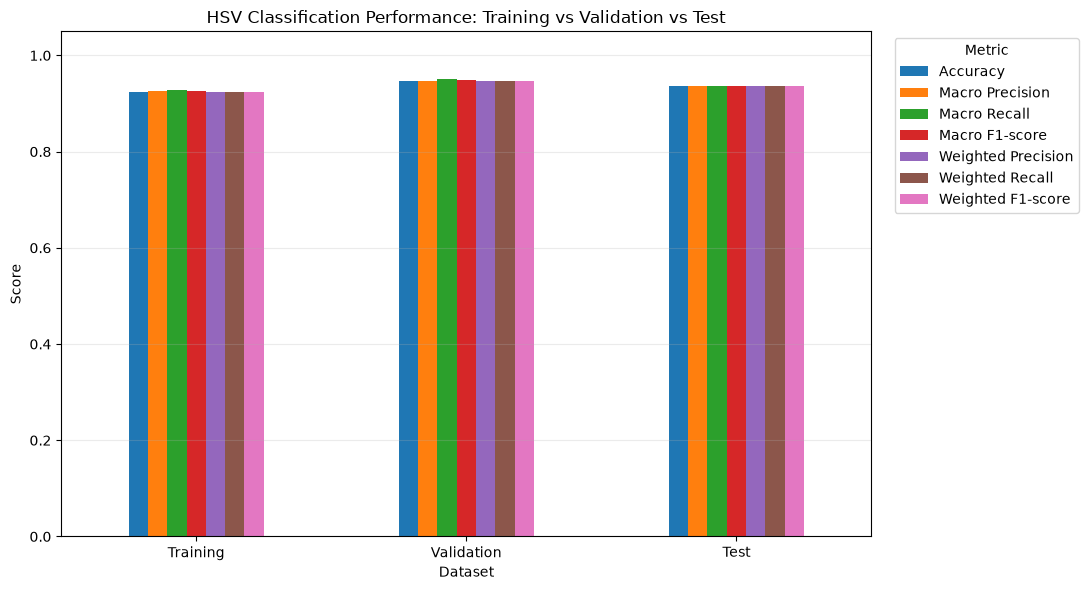

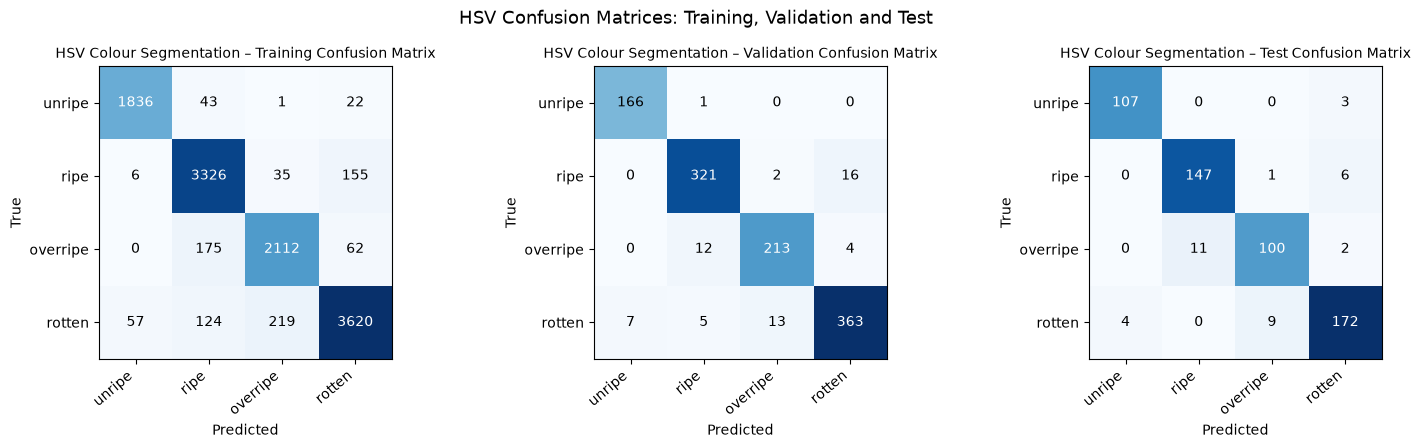


HSV Processing Time Summary


,Processing Time (s)
Dataset,
Training,130.2380
Validation,12.1546
Test,5.8573


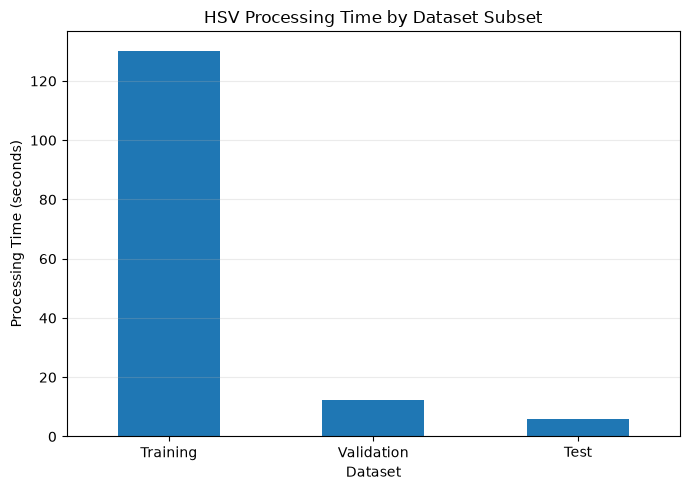

In [16]:
# ============================================================
# COMPLETE TRAIN / VALIDATION / TEST METRICS TABLES AND DIAGRAMS
# ============================================================

# 1. Separate overall metric tables for Training, Validation and Test
metric_columns = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1-score",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1-score",
    "Processing Time (s)",
]

training_metrics_table = (
    overall_metrics.loc[["Training"], metric_columns]
    .rename_axis(None)
)

validation_metrics_table = (
    overall_metrics.loc[["Validation"], metric_columns]
    .rename_axis(None)
)

test_metrics_table = (
    overall_metrics.loc[["Test"], metric_columns]
    .rename_axis(None)
)

print("Training Metrics")
display(training_metrics_table)

print("\nValidation Metrics")
display(validation_metrics_table)

print("\nTest Metrics")
display(test_metrics_table)

print("\nOverall Train / Validation / Test Metrics")
display(overall_metrics[metric_columns])


# ============================================================
# 2. Per-class results for ALL three subsets
# ============================================================

def per_class_results(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        labels=CLASS_ORDER,
        target_names=CLASS_ORDER,
        output_dict=True,
        zero_division=0,
    )

    return pd.DataFrame([
        {
            "Class": class_name,
            "Precision": report[class_name]["precision"],
            "Recall": report[class_name]["recall"],
            "F1-score": report[class_name]["f1-score"],
            "Support": int(report[class_name]["support"]),
        }
        for class_name in CLASS_ORDER
    ]).set_index("Class").round(4)


training_per_class = per_class_results(
    y_train,
    train_prediction
)

validation_per_class = per_class_results(
    y_validation,
    validation_prediction
)

test_per_class = per_class_results(
    y_test,
    test_prediction
)

print("\nTraining Per-Class Results")
display(training_per_class)

print("\nValidation Per-Class Results")
display(validation_per_class)

print("\nTest Per-Class Results")
display(test_per_class)


# ============================================================
# 3. Performance comparison diagram
# ============================================================

performance_columns = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1-score",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1-score",
]

ax = overall_metrics[performance_columns].plot(
    kind="bar",
    figsize=(11, 6),
    ylim=(0, 1.05),
)

ax.set_title(
    "HSV Classification Performance: "
    "Training vs Validation vs Test"
)

ax.set_xlabel("Dataset")
ax.set_ylabel("Score")

ax.tick_params(
    axis="x",
    rotation=0
)

ax.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "hsv_train_validation_test_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 4. Training / Validation / Test confusion matrices
# ============================================================

confusion_sets = [
    ("Training", y_train, train_prediction),
    ("Validation", y_validation, validation_prediction),
    ("Test", y_test, test_prediction),
]

titles = [
    "HSV Colour Segmentation – Training Confusion Matrix",
    "HSV Colour Segmentation – Validation Confusion Matrix",
    "HSV Colour Segmentation – Test Confusion Matrix"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.5)
)

for ax, (dataset_name, y_true, y_pred), title in zip(
    axes,
    confusion_sets,
    titles
):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=CLASS_ORDER
    )

    image = ax.imshow(
        cm,
        cmap="Blues"
    )

    ax.set_title(
        title,
        fontsize=10
    )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    ax.set_xticks(
        range(len(CLASS_ORDER)),
        CLASS_ORDER,
        rotation=40,
        ha="right"
    )

    ax.set_yticks(
        range(len(CLASS_ORDER)),
        CLASS_ORDER
    )

    threshold = (
        cm.max() * 0.5
        if cm.size and cm.max() > 0
        else 0
    )

    for i in range(len(CLASS_ORDER)):
        for j in range(len(CLASS_ORDER)):
            ax.text(
                j,
                i,
                int(cm[i, j]),
                ha="center",
                va="center",
                color=(
                    "white"
                    if cm[i, j] > threshold
                    else "black"
                )
            )

fig.suptitle(
    "HSV Confusion Matrices: "
    "Training, Validation and Test",
    fontsize=13
)

fig.tight_layout()

plt.savefig(
    FIGURES_DIR / "hsv_all_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 5. Processing-time table and diagram
# ============================================================

processing_time_table = (
    overall_metrics[
        ["Processing Time (s)"]
    ]
    .copy()
)

print("\nHSV Processing Time Summary")
display(processing_time_table)

ax = processing_time_table.plot(
    kind="bar",
    figsize=(7, 5),
    legend=False
)

ax.set_title(
    "HSV Processing Time by Dataset Subset"
)

ax.set_xlabel("Dataset")
ax.set_ylabel("Processing Time (seconds)")

ax.tick_params(
    axis="x",
    rotation=0
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "hsv_processing_time_by_subset.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. Save all evaluation tables
# ============================================================

training_metrics_table.to_csv(
    RESULTS_DIR / "training_metrics.csv"
)

validation_metrics_table.to_csv(
    RESULTS_DIR / "validation_metrics.csv"
)

test_metrics_table.to_csv(
    RESULTS_DIR / "test_metrics.csv"
)

overall_metrics[metric_columns].to_csv(
    RESULTS_DIR / "train_validation_test_metrics.csv"
)

training_per_class.to_csv(
    RESULTS_DIR / "training_per_class_results.csv"
)

validation_per_class.to_csv(
    RESULTS_DIR / "validation_per_class_results.csv"
)

test_per_class.to_csv(
    RESULTS_DIR / "test_per_class_results.csv"
)

processing_time_table.to_csv(
    RESULTS_DIR / "processing_time_summary.csv"
)

### 9.2 Interpretation of the HSV Evaluation

The HSV method is evaluated consistently across Training, Validation, and Test. The **Training** results show how well the fixed `StandardScaler() → SVC()` model represents the data used for model fitting. The **Validation** results provide an intermediate assessment on unseen images before the final test stage. The **Test** results provide the final evaluation after the HSV image-processing configuration has been fixed.

For this approach, the classification features come specifically from the segmented banana peel. Median filtering is first used to reduce visible image noise. Histogram equalisation is applied to the **V channel** to reduce ordinary illumination differences, while **H–S range thresholding** and morphological refinement are used to isolate the banana region from varying backgrounds. The final classifier receives the **32 normalised HSV histogram features** (16 H bins, 8 S bins, and 8 V bins), allowing it to represent gradual peel-colour changes between neighbouring ripeness stages.

The performance diagram should be interpreted together with the confusion matrices. Similar Training, Validation, and Test scores suggest that the HSV colour-histogram representation generalises consistently. If a large gap appears, it may indicate that the model fits the training colour distributions better than unseen images. The confusion matrices identify the specific ripeness stages that are difficult to distinguish, which is important because neighbouring stages may contain overlapping green, yellow, brown, and dark peel regions.

Processing time is reported separately for Training, Validation, and Test because the HSV pipeline includes image resizing when necessary, median filtering, RGB-to-HSV conversion, V-channel histogram equalisation, H–S thresholding, morphological refinement, banana-region extraction, and HSV histogram feature extraction.


## 10. Processing Example / Sample Segmentation

Representative training images are passed through the same HSV processing pipeline used for the complete dataset. The visual example demonstrates the major stages of the method:

**original/resized image → median-filtered image → HSV representation / enhanced V channel → binary banana mask → cleaned segmentation result**

The purpose of this section is to make the image-processing behaviour visible before classification. A successful mask should retain most of the banana peel while excluding as much background as possible.

The example uses the same frozen preprocessing and segmentation settings as the full experiment; it is not a separate manually adjusted demonstration.


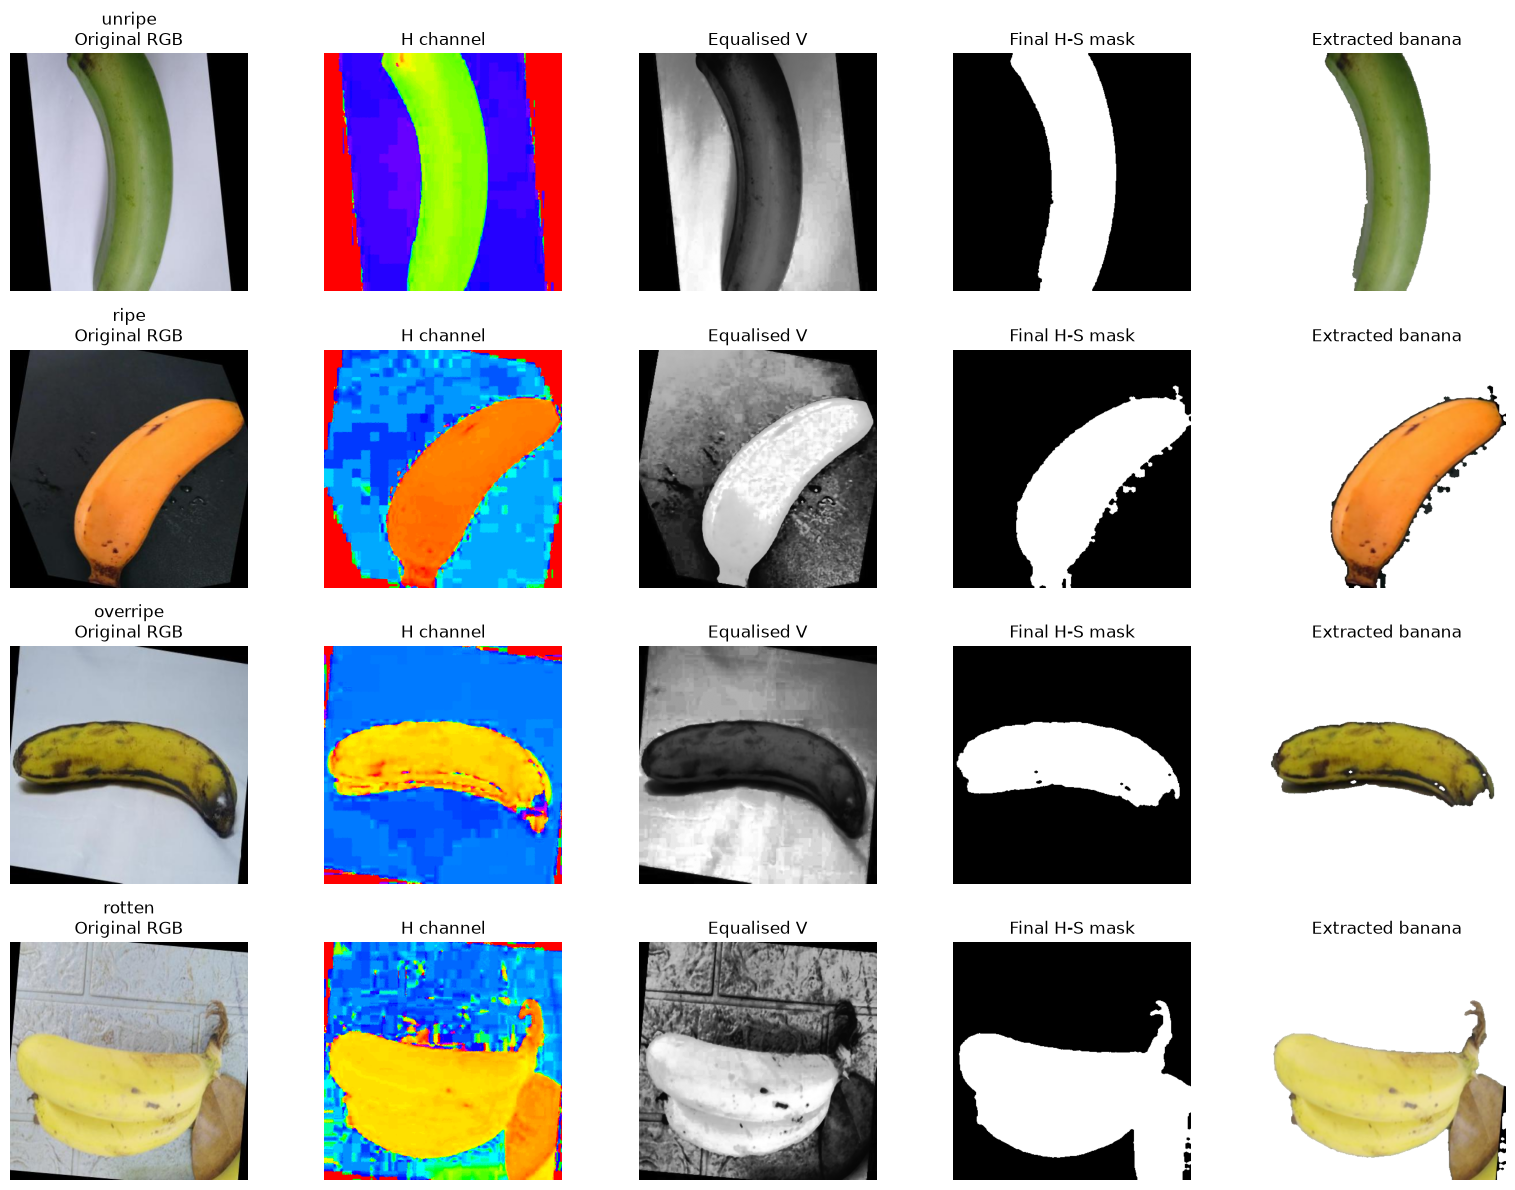

In [15]:
demonstration = [
    next(
        record
        for record in records
        if (
            record.subset == "train"
            and record.class_name == name
        )
    )
    for name in CLASS_ORDER
]

figure, axes = plt.subplots(
    len(CLASS_ORDER),
    5,
    figsize=(16, 12)
)

for row_index, record in enumerate(
    demonstration
):
    rgb = load_native_rgb(
        record
    )

    result = frozen_hsv_segmentation(
        rgb
    )

    h, s, v = cv2.split(
        result.hsv_equalised
    )

    panels = [
        (
            rgb,
            "Original RGB",
            None
        ),
        (
            h,
            "H channel",
            "hsv"
        ),
        (
            v,
            "Equalised V",
            "gray"
        ),
        (
            result.final_mask,
            "Final H-S mask",
            "gray"
        ),
        (
            result.extracted_rgb,
            "Extracted banana",
            None
        ),
    ]

    for column_index, (
        image_data,
        title,
        colour_map
    ) in enumerate(panels):
        axis = axes[
            row_index,
            column_index
        ]

        if colour_map is None:
            axis.imshow(
                image_data
            )
        else:
            axis.imshow(
                image_data,
                cmap=colour_map
            )

        axis.set_title(
            f"{record.class_name}\n{title}"
            if column_index == 0
            else title
        )

        axis.axis("off")

figure.tight_layout()

segmentation_figure_path = (
    FIGURES_DIR
    / "hsv_segmentation_demonstration.png"
)

figure.savefig(
    segmentation_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 11. Final Unified Configuration, Discussion and Limitations

The final HSV experiment uses the same overall experimental rules as the other group techniques:

| Item | HSV Setting |
|---|---|
| Target resize | 416 × 416 when necessary |
| Dataset split | Train / Validation / Test |
| Hyperparameter tuning | None |
| Noise reduction | 3 × 3 median filtering |
| Colour space | HSV |
| Enhancement | Histogram equalisation on V channel |
| Segmentation | Fixed H–S colour ranges + morphological refinement |
| Features | Normalised HSV histograms |
| Feature length | 32 |
| Classifier | StandardScaler() → default SVC() |
| Metrics | Accuracy, Macro Precision, Macro Recall, Macro F1-score, Weighted F1-score, Confusion Matrix, Processing Time |

### Results and Discussion

The HSV approach represents banana ripeness through the distribution of **hue, saturation, and brightness** within the segmented peel region. Hue is particularly relevant to the visible transition from green to yellow and later brown/dark tones, while saturation and value provide additional information about colour intensity and brightness.

The Training, Validation, and Test results should be interpreted together. Similar performance across the three subsets indicates that the extracted HSV representation generalises consistently, whereas a large gap between Training and Validation/Test may indicate overfitting or sensitivity to image conditions.

The confusion matrices provide class-level information that cannot be seen from accuracy alone. Misclassification between neighbouring ripeness stages can occur because banana ripening is gradual rather than visually discrete; for example, late ripe images may share peel colours with early overripe images.

Processing time is reported alongside classification metrics because the assignment evaluates not only predictive performance but also the computational behaviour of the complete image-processing approach.

### Limitations

The method remains dependent on colour-based segmentation. Background objects with HSV values similar to banana peel may be included in the mask, while unusual lighting, shadows, reflections, severe overexposure, or very dark images can alter the observed HSV distribution.

Fixed H–S segmentation ranges may not perfectly cover every banana appearance in a diverse dataset. Histogram features also describe colour distribution but do not explicitly encode peel texture, bruise shape, spot location, or other spatial information that may help distinguish difficult neighbouring ripeness stages.

### Conclusion

This notebook implements a complete and reproducible **HSV-based banana ripeness classification pipeline** using fixed image-processing settings and the common group classifier protocol. Images are resized to the 416 × 416 processing target when necessary, denoised using median filtering, converted to HSV, enhanced through the V channel, segmented using H–S colour information, and represented by 32 normalised HSV histogram features.

The extracted features are classified using **`StandardScaler() → SVC()` without hyperparameter tuning**, and performance is evaluated consistently using Accuracy, Macro Precision, Macro Recall, Macro F1-score, Weighted F1-score, Confusion Matrix, and Processing Time across the required dataset stages.
